In [21]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

data = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

In [22]:
data=np.array(data)

In [23]:
m,n= data.shape
np.random.shuffle(data)

data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]
X_dev = X_dev / 255.

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255.
_,m_train = X_train.shape

In [24]:
print(Y_train[:20])

[3 2 6 4 6 7 7 7 3 1 7 9 4 0 6 4 8 9 0 1]


In [25]:
def init_params():
    W1= np.random.rand(10,784)-0.5
    b1= np.random.rand(10,1)-0.5
    W2= np.random.rand(10,10)-0.5
    b2= np.random.rand(10,1)-0.5

    return W1, b1 , W2, b2

In [26]:
def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A
    
def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

In [27]:
def ReLU_deriv(Z):
    return Z > 0

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW2, db2

In [28]:
def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1    
    W2 = W2 - alpha * dW2  
    b2 = b2 - alpha * db2    
    return W1, b1, W2, b2

In [29]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [30]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.10, 500)


Iteration:  0
[8 9 1 ... 6 9 9] [3 2 6 ... 3 0 0]
0.10182926829268292
Iteration:  10
[8 9 1 ... 8 9 9] [3 2 6 ... 3 0 0]
0.14509756097560975
Iteration:  20
[8 9 1 ... 8 0 9] [3 2 6 ... 3 0 0]
0.17502439024390243
Iteration:  30
[8 9 3 ... 8 0 9] [3 2 6 ... 3 0 0]
0.237390243902439
Iteration:  40
[8 9 6 ... 8 0 0] [3 2 6 ... 3 0 0]
0.2923170731707317
Iteration:  50
[8 9 6 ... 8 0 0] [3 2 6 ... 3 0 0]
0.31902439024390244
Iteration:  60
[8 9 6 ... 8 0 0] [3 2 6 ... 3 0 0]
0.35641463414634145
Iteration:  70
[8 9 6 ... 3 0 0] [3 2 6 ... 3 0 0]
0.4128780487804878
Iteration:  80
[8 9 6 ... 3 0 0] [3 2 6 ... 3 0 0]
0.4558048780487805
Iteration:  90
[8 9 6 ... 3 0 0] [3 2 6 ... 3 0 0]
0.4894390243902439
Iteration:  100
[8 9 6 ... 3 0 0] [3 2 6 ... 3 0 0]
0.5234390243902439
Iteration:  110
[8 9 6 ... 3 0 0] [3 2 6 ... 3 0 0]
0.5525853658536586
Iteration:  120
[8 0 6 ... 3 0 0] [3 2 6 ... 3 0 0]
0.5795853658536585
Iteration:  130
[8 0 6 ... 3 0 0] [3 2 6 ... 3 0 0]
0.6028048780487805
Iteration:  1

In [33]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [3]
Label:  3


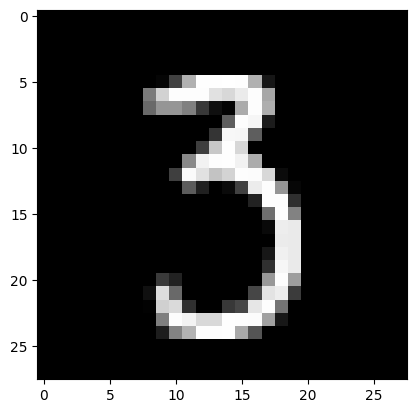

Prediction:  [0]
Label:  2


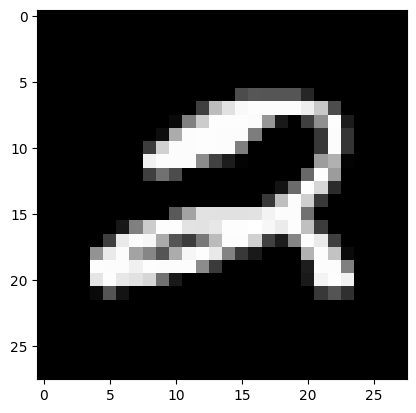

Prediction:  [6]
Label:  6


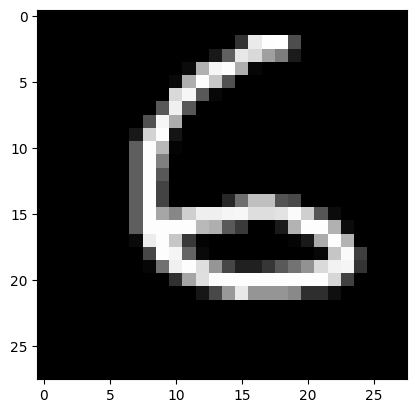

Prediction:  [4]
Label:  4


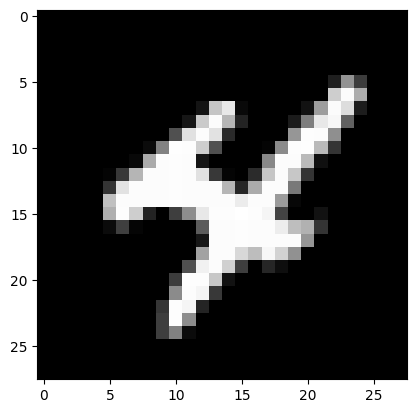

[9 9 1 2 8 2 7 4 2 3 3 6 7 5 8 3 9 6 8 5 9 3 7 8 3 3 1 3 8 1 6 6 6 2 4 3 0
 2 0 3 5 4 6 8 7 9 5 9 8 9 4 7 6 5 1 7 5 7 0 0 5 8 5 4 9 9 9 0 9 2 0 8 5 9
 5 7 7 8 7 0 1 3 2 8 4 3 5 9 0 3 8 9 2 7 4 5 7 2 9 4 4 8 3 6 3 4 6 1 7 4 8
 1 2 4 5 9 9 8 5 4 3 2 8 7 7 8 5 4 6 7 1 5 1 3 2 5 9 1 9 9 0 3 1 9 0 0 5 9
 9 6 8 5 7 7 1 1 2 4 0 9 1 5 9 1 4 4 1 4 4 1 7 9 2 4 9 4 1 1 4 3 0 8 2 7 1
 8 1 5 6 3 9 6 3 5 0 1 2 4 8 0 1 3 9 2 4 1 0 7 4 5 3 0 9 2 9 5 4 5 2 1 1 0
 9 5 9 1 1 1 9 5 5 9 6 0 3 8 8 8 5 4 4 3 9 3 7 3 7 0 0 3 0 7 2 8 0 8 2 6 8
 4 7 5 2 0 8 9 5 0 6 3 1 7 1 2 9 3 4 5 4 9 0 9 7 5 8 0 5 5 1 0 9 6 7 6 5 5
 2 7 5 5 6 0 3 4 9 2 7 4 2 7 3 6 3 2 0 8 9 0 2 3 2 0 1 6 5 5 3 9 5 8 8 5 9
 8 2 7 6 8 3 3 9 7 3 2 3 5 8 5 9 4 0 7 1 0 1 8 1 3 9 1 0 4 0 0 0 8 1 3 3 9
 2 0 8 5 2 8 4 9 2 3 3 5 5 1 8 5 3 9 6 3 2 4 2 2 4 6 2 1 4 1 6 9 4 7 6 7 7
 4 1 7 4 2 7 4 2 0 1 8 2 5 7 7 3 0 9 4 2 6 3 0 2 5 2 4 4 9 8 6 8 3 7 2 1 8
 1 3 7 9 6 9 2 2 7 8 2 9 1 2 0 9 9 7 2 5 7 5 7 4 6 2 8 7 4 6 1 9 6 9 6 0 1
 5 7 6 8 9 8 4 5 8 1 4 5 

np.float64(0.844)

In [36]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)

dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_dev)